# Explainable Bitcoin Volatility Forecasting Using Technical Indicators and Ensemble Machine Learning

### Camera Ready Version

**Conference:** IEEE TEMSCON ASPAC 2026

---

## Objective

Develop an explainable machine learning framework for Bitcoin volatility forecasting using technical indicators and ensemble learning models.

---

### Models
- Decision Tree
- Random Forest
- XGBoost

### Explainability
- SHAP

### Validation
- TimeSeriesSplit

# 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import shap


!pip install ta

import ta




  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=085c0c501547f4aa1aeaa3814da7afbd398ae7ada2561b3a98f8fb0a329a0c58
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
# Check versions

print("Pandas Version :", pd.__version__)
print("NumPy Version  :", np.__version__)

Pandas Version : 2.2.2
NumPy Version  : 2.0.2


# 2. Load Dataset



In this section, we load the Bitcoin historical price dataset and inspect its structure to understand the available features before performing preprocessing and feature engineering.


In [3]:
from google.colab import files

uploaded = files.upload()

Saving coin_Bitcoin.csv to coin_Bitcoin.csv


In [4]:
df = pd.read_csv("/content/coin_Bitcoin.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [6]:
df.head()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
0,1,Bitcoin,BTC,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2,Bitcoin,BTC,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,3,Bitcoin,BTC,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,4,Bitcoin,BTC,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,5,Bitcoin,BTC,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


# 3. Data Cleaning

In [7]:
print("Dataset Shape:", df.shape)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset Shape: (2991, 10)
Rows: 2991
Columns: 10


In [8]:
# Statistical summary

df.describe()

,SNo,High,Low,Open,Close,Volume,Marketcap
count,2991.000000,2991.000000,2991.000000,2991.000000,2991.000000,2.991000e+03,2.991000e+03
mean,1496.000000,6893.326038,6486.009539,6700.146240,6711.290443,1.090633e+10,1.208761e+11
std,863.571653,11642.832456,10869.032130,11288.043736,11298.141921,1.888895e+10,2.109438e+11
min,1.000000,74.561096,65.526001,68.504997,68.431000,0.000000e+00,7.784112e+08
25%,748.500000,436.179001,422.879486,430.445496,430.569489,3.036725e+07,6.305579e+09
50%,1496.000000,2387.610107,2178.500000,2269.889893,2286.409912,9.460360e+08,3.741503e+10
75%,2243.500000,8733.926948,8289.800459,8569.656494,8576.238715,1.592015e+10,1.499957e+11
max,2991.000000,64863.098908,62208.964366,63523.754869,63503.457930,3.509679e+11,1.186364e+12


In [9]:
df.columns

Index(['SNo', 'Name', 'Symbol', 'Date', 'High', 'Low', 'Open', 'Close',
       'Volume', 'Marketcap'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SNo        2991 non-null   int64  
 1   Name       2991 non-null   object 
 2   Symbol     2991 non-null   object 
 3   Date       2991 non-null   object 
 4   High       2991 non-null   float64
 5   Low        2991 non-null   float64
 6   Open       2991 non-null   float64
 7   Close      2991 non-null   float64
 8   Volume     2991 non-null   float64
 9   Marketcap  2991 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 233.8+ KB


In [11]:
df.isnull().sum()

,0
SNo,0
Name,0
Symbol,0
Date,0
High,0
Low,0
Open,0
Close,0
Volume,0
Marketcap,0


In [12]:
df.tail()

,SNo,Name,Symbol,Date,High,Low,Open,Close,Volume,Marketcap
2986,2987,Bitcoin,BTC,2021-07-02 23:59:59,33939.588699,32770.680780,33549.600177,33897.048590,3.872897e+10,6.354508e+11
2987,2988,Bitcoin,BTC,2021-07-03 23:59:59,34909.259899,33402.696536,33854.421362,34668.548402,2.438396e+10,6.499397e+11
2988,2989,Bitcoin,BTC,2021-07-04 23:59:59,35937.567147,34396.477458,34665.564866,35287.779766,2.492431e+10,6.615748e+11
2989,2990,Bitcoin,BTC,2021-07-05 23:59:59,35284.344430,33213.661034,35284.344430,33746.002456,2.672155e+10,6.326962e+11
2990,2991,Bitcoin,BTC,2021-07-06 23:59:59,35038.536363,33599.916169,33723.509655,34235.193451,2.650126e+10,6.418992e+11


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   SNo        2991 non-null   int64         
 1   Name       2991 non-null   object        
 2   Symbol     2991 non-null   object        
 3   Date       2991 non-null   datetime64[ns]
 4   High       2991 non-null   float64       
 5   Low        2991 non-null   float64       
 6   Open       2991 non-null   float64       
 7   Close      2991 non-null   float64       
 8   Volume     2991 non-null   float64       
 9   Marketcap  2991 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 233.8+ KB


In [15]:
# Sort chronologically

df = df.sort_values("Date").reset_index(drop=True)

In [16]:
df.drop(columns=["SNo", "Name", "Symbol"], inplace=True)

df.head()

,Date,High,Low,Open,Close,Volume,Marketcap
0,2013-04-29 23:59:59,147.488007,134.000000,134.444000,144.539993,0.0,1.603769e+09
1,2013-04-30 23:59:59,146.929993,134.050003,144.000000,139.000000,0.0,1.542813e+09
2,2013-05-01 23:59:59,139.889999,107.720001,139.000000,116.989998,0.0,1.298955e+09
3,2013-05-02 23:59:59,125.599998,92.281898,116.379997,105.209999,0.0,1.168517e+09
4,2013-05-03 23:59:59,108.127998,79.099998,106.250000,97.750000,0.0,1.085995e+09


In [17]:
print(df.shape)

df.info()

(2991, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2991 non-null   datetime64[ns]
 1   High       2991 non-null   float64       
 2   Low        2991 non-null   float64       
 3   Open       2991 non-null   float64       
 4   Close      2991 non-null   float64       
 5   Volume     2991 non-null   float64       
 6   Marketcap  2991 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 163.7 KB


Exploratory Data Analysis (EDA)

In [18]:
plt.rcParams["figure.figsize"] = (14,6)
plt.rcParams["font.size"] = 12


Bitcoin Closing Price Over Time

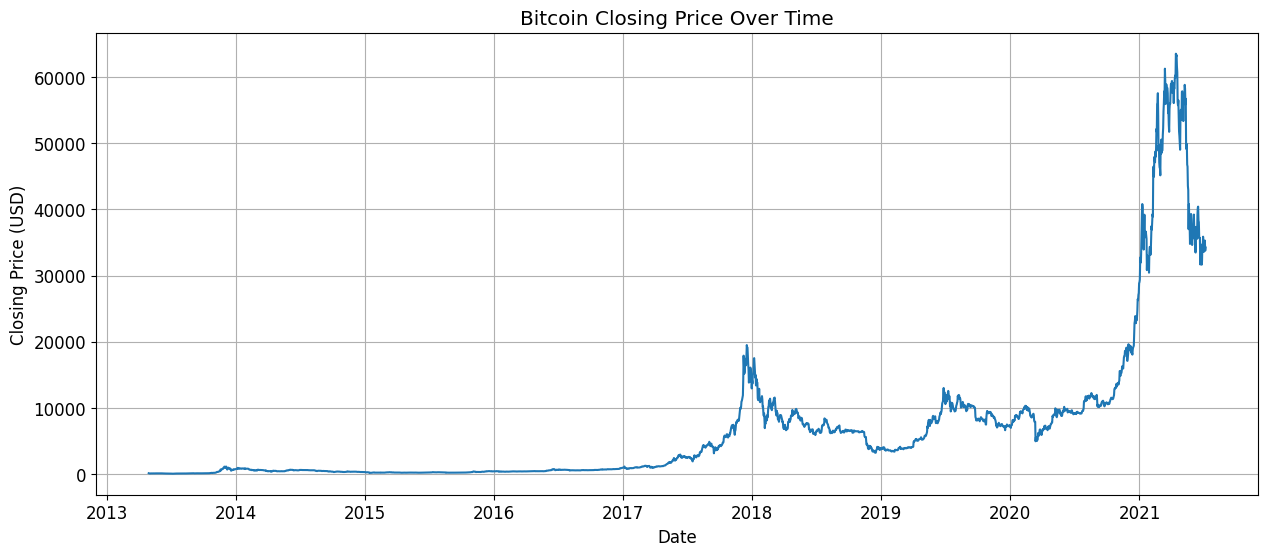

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Close"])

plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.grid(True)

plt.show()

Trading Volume Over Time

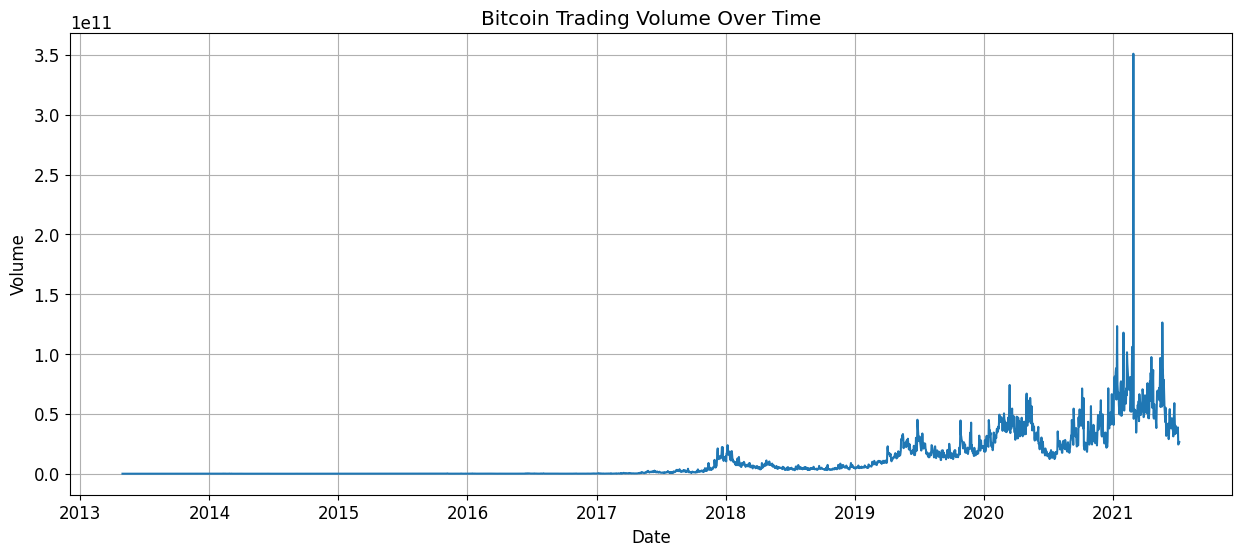

In [20]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Volume"])

plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

Market Capitalization

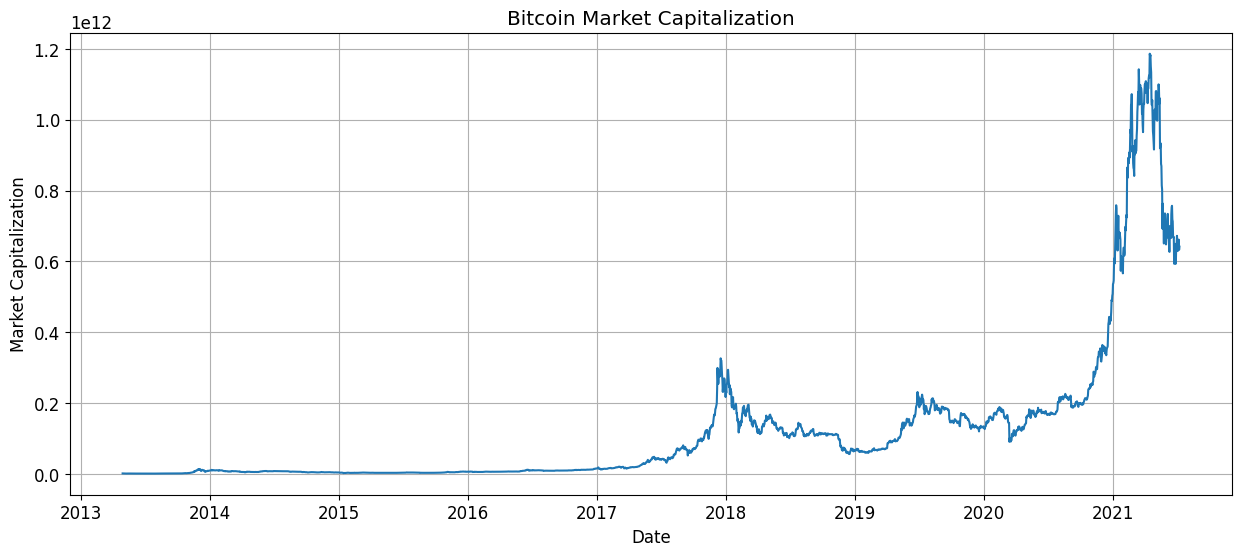

In [21]:
plt.figure(figsize=(15,6))

plt.plot(df["Date"], df["Marketcap"])

plt.title("Bitcoin Market Capitalization")
plt.xlabel("Date")
plt.ylabel("Market Capitalization")

plt.grid(True)

plt.show()

Correlation Heatmap

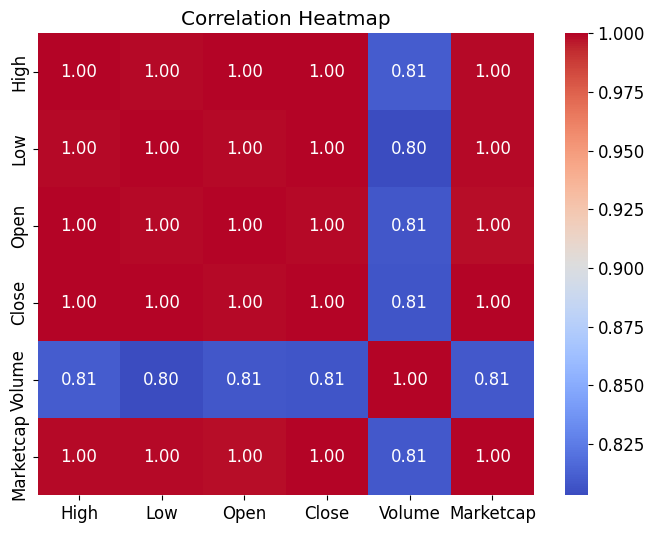

In [22]:
plt.figure(figsize=(8,6))

corr = df.drop("Date", axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Boxplots (Outlier Detection)

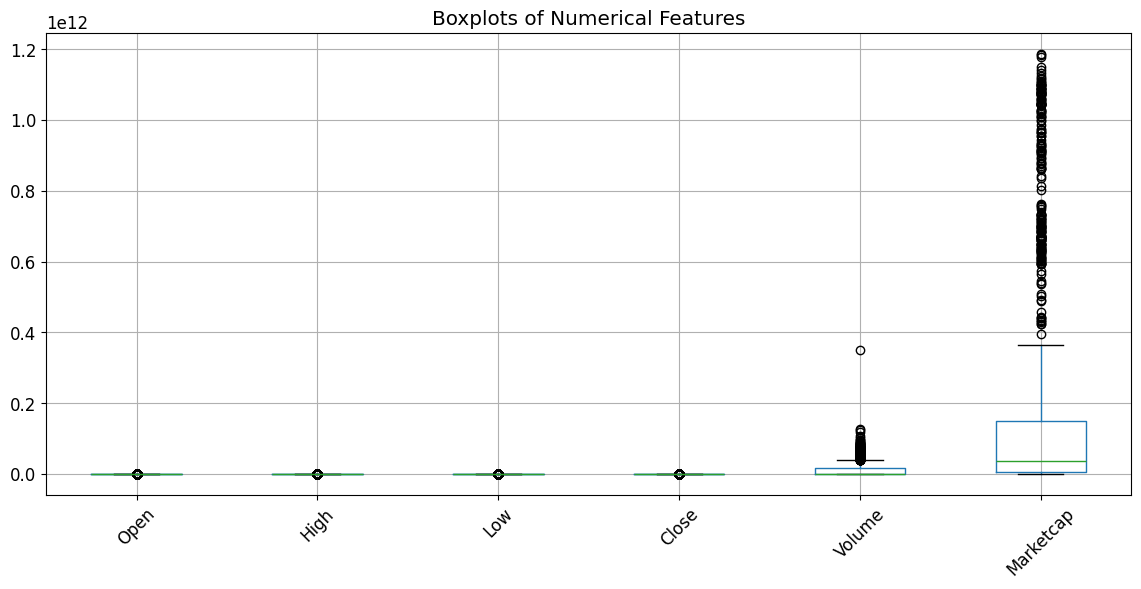

In [23]:
numeric_cols = ["Open","High","Low","Close","Volume","Marketcap"]

plt.figure(figsize=(14,6))

df[numeric_cols].boxplot(rot=45)

plt.title("Boxplots of Numerical Features")

plt.show()

Distribution of Closing Price

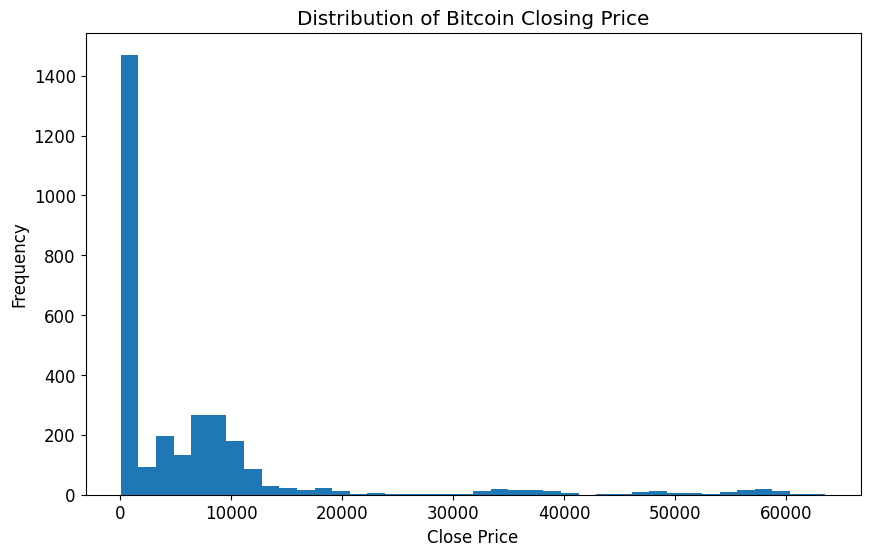

In [24]:
plt.figure(figsize=(10,6))

plt.hist(df["Close"], bins=40)

plt.title("Distribution of Bitcoin Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")

plt.show()

In [25]:
# Daily Percentage Returns

df["Returns"] = df["Close"].pct_change()

# Display first 10 rows
df[["Date", "Close", "Returns"]].head(10)

,Date,Close,Returns
0,2013-04-29 23:59:59,144.539993,NaN
1,2013-04-30 23:59:59,139.000000,-0.038328
2,2013-05-01 23:59:59,116.989998,-0.158345
3,2013-05-02 23:59:59,105.209999,-0.100692
4,2013-05-03 23:59:59,97.750000,-0.070906
5,2013-05-04 23:59:59,112.500000,0.150895
6,2013-05-05 23:59:59,115.910004,0.030311
7,2013-05-06 23:59:59,112.300003,-0.031145
8,2013-05-07 23:59:59,111.500000,-0.007124
9,2013-05-08 23:59:59,113.566002,0.018529


In [26]:
# Create Historical Volatility

df["Volatility_7"] = df["Returns"].rolling(window=7).std()
df["Volatility_14"] = df["Returns"].rolling(window=14).std()
df["Volatility_21"] = df["Returns"].rolling(window=21).std()

df[["Returns", "Volatility_7", "Volatility_14", "Volatility_21"]].head(25)

,Returns,Volatility_7,Volatility_14,Volatility_21
0,NaN,NaN,NaN,NaN
1,-0.038328,NaN,NaN,NaN
2,-0.158345,NaN,NaN,NaN
3,-0.100692,NaN,NaN,NaN
4,-0.070906,NaN,NaN,NaN
5,0.150895,NaN,NaN,NaN
6,0.030311,NaN,NaN,NaN
7,-0.031145,0.099637,NaN,NaN
8,-0.007124,0.099961,NaN,NaN
9,0.018529,0.081858,NaN,NaN


In [27]:
# Remove rows containing NaN values

df.dropna(inplace=True)

# Reset index

df.reset_index(drop=True, inplace=True)

print(df.shape)

df.head()

(2970, 11)


,Date,High,Low,Open,Close,Volume,Marketcap,Returns,Volatility_7,Volatility_14,Volatility_21
0,2013-05-20 23:59:59,123.621002,120.120003,122.500000,122.000000,0.0,1.363710e+09,0.000082,0.032777,0.026484,0.061328
1,2013-05-21 23:59:59,123.000000,121.209999,122.019997,122.879997,0.0,1.374013e+09,0.007213,0.019475,0.026203,0.060940
2,2013-05-22 23:59:59,124.000999,122.000000,122.889999,123.889000,0.0,1.385779e+09,0.008211,0.019010,0.026006,0.049646
3,2013-05-23 23:59:59,126.933998,123.099998,123.800003,126.699997,0.0,1.417770e+09,0.022690,0.015626,0.025985,0.043582
4,2013-05-24 23:59:59,133.850006,125.719002,126.300003,133.199997,0.0,1.491071e+09,0.051302,0.020365,0.027161,0.040308


In [28]:
!pip install ta

In [29]:
import ta

In [30]:
# Simple Moving Averages
df["SMA_10"] = ta.trend.sma_indicator(df["Close"], window=10)
df["SMA_20"] = ta.trend.sma_indicator(df["Close"], window=20)

# Exponential Moving Averages
df["EMA_10"] = ta.trend.ema_indicator(df["Close"], window=10)
df["EMA_20"] = ta.trend.ema_indicator(df["Close"], window=20)

# Display results
df[["Close", "SMA_10", "SMA_20", "EMA_10", "EMA_20"]].tail()

,Close,SMA_10,SMA_20,EMA_10,EMA_20
2965,33897.048590,33967.128373,35353.911146,34305.373839,34991.172360
2966,34668.548402,34061.680315,35132.445521,34371.405578,34960.446269
2967,35287.779766,34124.214702,34885.910617,34538.019066,34991.620888
2968,33746.002456,34335.036942,34552.897290,34394.016046,34872.990561
2969,34235.193451,34539.928520,34347.303801,34365.139211,34812.247979


In [31]:
df["MACD"] = ta.trend.macd(df["Close"])
df["MACD_Signal"] = ta.trend.macd_signal(df["Close"])
df["MACD_Hist"] = ta.trend.macd_diff(df["Close"])

df[["Close", "MACD", "MACD_Signal", "MACD_Hist"]].tail()

,Close,MACD,MACD_Signal,MACD_Hist
2965,33897.048590,-1179.730837,-1417.830331,238.099494
2966,34668.548402,-1071.555752,-1348.575416,277.019663
2967,35287.779766,-925.194358,-1263.899204,338.704846
2968,33746.002456,-922.971007,-1195.713565,272.742558
2969,34235.193451,-871.687094,-1130.908270,259.221177


In [32]:
# ==========================
# Momentum Indicators
# ==========================

# Relative Strength Index
df["RSI"] = ta.momentum.rsi(df["Close"], window=14)

# Rate of Change
df["ROC"] = ta.momentum.roc(df["Close"], window=12)

# Stochastic Oscillator
df["Stochastic"] = ta.momentum.stoch(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14,
    smooth_window=3
)

# Williams %R
df["WilliamsR"] = ta.momentum.williams_r(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    lbp=14
)

# Display the last 5 rows
df[["RSI", "ROC", "Stochastic", "WilliamsR"]].tail()

,RSI,ROC,Stochastic,WilliamsR
2965,44.840772,-5.045753,65.417192,-34.582808
2966,47.175200,9.444971,75.504148,-24.495852
2967,49.039426,8.558879,83.600275,-16.399725
2968,44.800134,0.068124,63.442342,-36.557658
2969,46.383877,-1.232581,63.714071,-36.285929


In [33]:
df["BB_High"] = ta.volatility.bollinger_hband(df["Close"], window=20)
df["BB_Low"] = ta.volatility.bollinger_lband(df["Close"], window=20)
df["BB_Middle"] = ta.volatility.bollinger_mavg(df["Close"], window=20)
df["BB_Width"] = ta.volatility.bollinger_wband(df["Close"], window=20)

df[["Close", "BB_High", "BB_Middle", "BB_Low", "BB_Width"]].tail()

,Close,BB_High,BB_Middle,BB_Low,BB_Width
2965,33897.048590,40558.641381,35353.911146,30149.180911,29.443589
2966,34668.548402,40050.121924,35132.445521,30214.769119,27.995070
2967,35287.779766,39218.543086,34885.910617,30553.278147,24.838867
2968,33746.002456,38087.458003,34552.897290,31018.336578,20.458838
2969,34235.193451,37423.842898,34347.303801,31270.764704,17.914298


In [34]:

df["ATR"] = ta.volatility.average_true_range(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=14
)

df[["High", "Low", "Close", "ATR"]].tail()

,High,Low,Close,ATR
2965,33939.588699,32770.680780,33897.048590,2688.734671
2966,34909.259899,33402.696536,34668.548402,2604.293864
2967,35937.567147,34396.477458,35287.779766,2528.350708
2968,35284.344430,33213.661034,33746.002456,2495.905567
2969,35038.536363,33599.916169,34235.193451,2420.385183


In [35]:
# =====================================
# Donchian Channel
# =====================================

df["Donchian_High"] = ta.volatility.donchian_channel_hband(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=20
)

df["Donchian_Low"] = ta.volatility.donchian_channel_lband(
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    window=20
)

df[["Donchian_High", "Donchian_Low"]].tail()

,Donchian_High,Donchian_Low
2965,41295.268574,28893.621658
2966,41295.268574,28893.621658
2967,41295.268574,28893.621658
2968,40516.776828,28893.621658
2969,39513.670164,28893.621658


In [36]:


# Lagged Returns
df["Return_Lag_1"] = df["Returns"].shift(1)
df["Return_Lag_2"] = df["Returns"].shift(2)
df["Return_Lag_3"] = df["Returns"].shift(3)
df["Return_Lag_5"] = df["Returns"].shift(5)
df["Return_Lag_7"] = df["Returns"].shift(7)

# Lagged Volatility
df["Volatility_Lag_1"] = df["Volatility_21"].shift(1)
df["Volatility_Lag_2"] = df["Volatility_21"].shift(2)
df["Volatility_Lag_3"] = df["Volatility_21"].shift(3)

df[
    [
        "Returns",
        "Return_Lag_1",
        "Return_Lag_2",
        "Return_Lag_3",
        "Volatility_21",
        "Volatility_Lag_1"
    ]
].tail()

,Returns,Return_Lag_1,Return_Lag_2,Return_Lag_3,Volatility_21,Volatility_Lag_1
2965,0.009679,-0.041915,-0.023055,0.041628,0.051257,0.051379
2966,0.022760,0.009679,-0.041915,-0.023055,0.050506,0.051257
2967,0.017861,0.022760,0.009679,-0.041915,0.045320,0.050506
2968,-0.043692,0.017861,0.022760,0.009679,0.045474,0.045320
2969,0.014496,-0.043692,0.017861,0.022760,0.045653,0.045474


In [37]:


df["Rolling_Mean_7"] = df["Close"].rolling(window=7).mean()
df["Rolling_STD_7"] = df["Close"].rolling(window=7).std()

df["Rolling_Max_7"] = df["Close"].rolling(window=7).max()
df["Rolling_Min_7"] = df["Close"].rolling(window=7).min()

df[[
    "Close",
    "Rolling_Mean_7",
    "Rolling_STD_7",
    "Rolling_Max_7",
    "Rolling_Min_7"
]].tail()

,Close,Rolling_Mean_7,Rolling_STD_7,Rolling_Max_7,Rolling_Min_7
2965,33897.048590,34235.434114,1174.584149,35867.777735,32186.277671
2966,34668.548402,34590.044219,751.242871,35867.777735,33572.117653
2967,35287.779766,34681.206387,797.005229,35867.777735,33572.117653
2968,33746.002456,34582.873122,871.519655,35867.777735,33572.117653
2969,34235.193451,34349.646795,664.130849,35287.779766,33572.117653


In [38]:
# =====================================
# Price-Based Features
# =====================================

# Log Returns
df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))

# Daily Price Change
df["Price_Change"] = df["Close"] - df["Open"]

# High-Low Spread
df["High_Low_Spread"] = df["High"] - df["Low"]

# Open-Close Spread
df["Open_Close_Spread"] = df["Open"] - df["Close"]

df[[
    "Log_Returns",
    "Price_Change",
    "High_Low_Spread",
    "Open_Close_Spread"
]].tail()

,Log_Returns,Price_Change,High_Low_Spread,Open_Close_Spread
2965,0.009632,347.448412,1168.907919,-347.448412
2966,0.022505,814.127040,1506.563363,-814.127040
2967,0.017704,622.214900,1541.089690,-622.214900
2968,-0.044675,-1538.341974,2070.683396,1538.341974
2969,0.014392,511.683796,1438.620194,-511.683796


In [39]:
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

print("Final Dataset Shape :", df.shape)

df.head()

Final Dataset Shape : (2937, 45)


,Date,High,Low,Open,Close,Volume,Marketcap,Returns,Volatility_7,Volatility_14,...,Volatility_Lag_2,Volatility_Lag_3,Rolling_Mean_7,Rolling_STD_7,Rolling_Max_7,Rolling_Min_7,Log_Returns,Price_Change,High_Low_Spread,Open_Close_Spread
0,2013-06-22 23:59:59,109.956001,107.514000,109.500000,108.300003,0.0,1.226110e+09,-0.010959,0.023153,0.036862,...,0.034845,0.034628,106.401429,4.108266,110.150002,99.510002,-0.011019,-1.199997,2.442001,1.199997
1,2013-06-23 23:59:59,108.800003,106.234001,108.199997,107.599998,0.0,1.218626e+09,-0.006464,0.023360,0.029602,...,0.034793,0.034845,107.557143,2.764724,110.150002,101.699997,-0.006485,-0.599998,2.566002,0.599998
2,2013-06-24 23:59:59,108.334000,100.980003,107.900002,102.737000,0.0,1.163936e+09,-0.045195,0.030895,0.027436,...,0.034732,0.034793,107.705286,2.402644,110.150002,102.737000,-0.046248,-5.163002,7.353996,5.163002
3,2013-06-25 23:59:59,106.470001,101.010002,102.089996,103.949997,0.0,1.178086e+09,0.011807,0.020856,0.026729,...,0.033067,0.034732,107.212429,2.797166,110.150002,102.737000,0.011738,1.860001,5.459999,-1.860001
4,2013-06-26 23:59:59,105.488998,102.792000,103.329002,104.000000,0.0,1.179105e+09,0.000481,0.020303,0.026719,...,0.034148,0.033067,106.605286,2.989080,110.150002,102.737000,0.000481,0.670998,2.696999,-0.670998


In [40]:
# Target Variable
y = df["Volatility_21"]

# Drop non-feature columns
X = df.drop(columns=[
    "Date",
    "Volatility_21"
])

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (2937, 43)
Target Shape : (2937,)


In [41]:
corr = df.corr(numeric_only=True)

print(corr["Volatility_21"].sort_values(ascending=False))

Volatility_21        1.000000
Volatility_Lag_1     0.985437
Volatility_Lag_2     0.966508
Volatility_Lag_3     0.946578
Volatility_14        0.925856
Volatility_7         0.779222
BB_Width             0.745170
ATR                  0.257832
Rolling_STD_7        0.248845
High_Low_Spread      0.226178
Donchian_High        0.156712
BB_High              0.155778
Rolling_Max_7        0.138532
SMA_20               0.132784
BB_Middle            0.132784
EMA_20               0.132267
High                 0.131795
EMA_10               0.129922
SMA_10               0.129899
Rolling_Mean_7       0.128938
Open                 0.127491
Close                0.127253
Low                  0.121501
Marketcap            0.120088
Rolling_Min_7        0.118416
ROC                  0.113463
Volume               0.108229
BB_Low               0.100296
Donchian_Low         0.096339
Returns              0.040257
Return_Lag_7         0.033755
Return_Lag_2         0.031457
Return_Lag_1         0.031049
Return_Lag

In [42]:
# ===============================
# Time Series Split (80%-20%)
# ===============================

split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (2349, 43)
Testing Shape : (588, 43)


In [43]:
print("Training Period")
print(df.iloc[:split]["Date"].min())
print(df.iloc[:split]["Date"].max())

print()

print("Testing Period")
print(df.iloc[split:]["Date"].min())
print(df.iloc[split:]["Date"].max())

Training Period
2013-06-22 23:59:59
2019-11-26 23:59:59

Testing Period
2019-11-27 23:59:59
2021-07-06 23:59:59


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,

)

import numpy as np

In [45]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [46]:
y_pred_rf = rf.predict(X_test)

In [47]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-"*35)
print(f"RMSE : {rmse_rf:.6f}")
print(f"MAE  : {mae_rf:.6f}")
print(f"R²   : {r2_rf:.6f}")

Random Forest Performance
-----------------------------------
RMSE : 0.003295
MAE  : 0.001578
R²   : 0.964753


In [48]:
results = y_test.to_frame(name="Actual")

results["Predicted"] = y_pred_rf

results.head(10)


,Actual,Predicted
2349,0.026224,0.023813
2350,0.026224,0.025685
2351,0.026700,0.027688
2352,0.026967,0.027528
2353,0.025899,0.027660
2354,0.025352,0.026792
2355,0.025195,0.026469
2356,0.025134,0.025983
2357,0.026318,0.025283
2358,0.026346,0.024967


In [49]:
# =====================================
# Feature Importance
# =====================================

importance = rf.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(by="Importance", ascending=False)
)

feature_importance.head(15)

,Feature,Importance
32,Volatility_Lag_1,0.973059
8,Volatility_14,0.010444
33,Volatility_Lag_2,0.003277
7,Volatility_7,0.002109
23,BB_Width,0.001410
6,Returns,0.001069
39,Log_Returns,0.001027
4,Volume,0.000564
18,Stochastic,0.000462
34,Volatility_Lag_3,0.000444


In [50]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [51]:
dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [52]:
y_pred_dt = dt.predict(X_test)

In [53]:
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-"*35)
print(f"RMSE : {rmse_dt:.6f}")
print(f"MAE  : {mae_dt:.6f}")
print(f"R²   : {r2_dt:.6f}")

Decision Tree Performance
-----------------------------------
RMSE : 0.004662
MAE  : 0.002393
R²   : 0.929451


In [54]:
comparison_dt = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dt
})

comparison_dt.head(10)

,Actual,Predicted
2349,0.026224,0.027482
2350,0.026224,0.025227
2351,0.026700,0.025227
2352,0.026967,0.026712
2353,0.025899,0.026712
2354,0.025352,0.025227
2355,0.025195,0.025227
2356,0.025134,0.025227
2357,0.026318,0.025227
2358,0.026346,0.025227


In [55]:
!pip install xgboost

In [56]:
from xgboost import XGBRegressor


In [57]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [58]:
y_pred_xgb = xgb.predict(X_test)

In [59]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-"*35)
print(f"RMSE : {rmse_xgb:.6f}")
print(f"MAE  : {mae_xgb:.6f}")
print(f"R²   : {r2_xgb:.6f}")

XGBoost Performance
-----------------------------------
RMSE : 0.002884
MAE  : 0.001529
R²   : 0.973001


In [60]:
comparison_xgb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb
})

comparison_xgb.head(10)

,Actual,Predicted
2349,0.026224,0.026418
2350,0.026224,0.026029
2351,0.026700,0.028803
2352,0.026967,0.027491
2353,0.025899,0.027091
2354,0.025352,0.026303
2355,0.025195,0.026194
2356,0.025134,0.025840
2357,0.026318,0.026208
2358,0.026346,0.025632


In [61]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        rmse_dt,
        rmse_rf,
        rmse_xgb
    ],
    "MAE": [
        mae_dt,
        mae_rf,
        mae_xgb
    ],
    "R²": [
        r2_dt,
        r2_rf,
        r2_xgb
    ]
})

results.sort_values("RMSE")

,Model,RMSE,MAE,R²
2,XGBoost,0.002884,0.001529,0.973001
1,Random Forest,0.003295,0.001578,0.964753
0,Decision Tree,0.004662,0.002393,0.929451


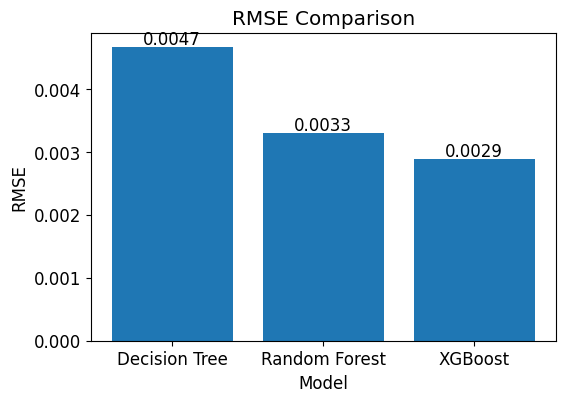

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["RMSE"])

plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")

for i, v in enumerate(results["RMSE"]):
    plt.text(i, v+0.00005, f"{v:.4f}", ha='center')

plt.show()


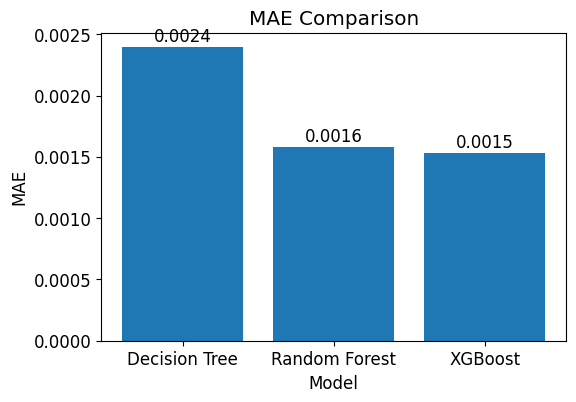

In [63]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["MAE"])

plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xlabel("Model")

for i, v in enumerate(results["MAE"]):
    plt.text(i, v+0.00005, f"{v:.4f}", ha='center')

plt.show()

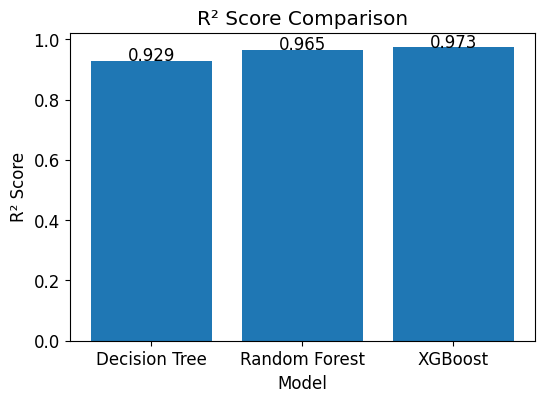

In [64]:
plt.figure(figsize=(6,4))

plt.bar(results["Model"], results["R²"])

plt.title("R² Score Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")

for i, v in enumerate(results["R²"]):
    plt.text(i, v+0.001, f"{v:.3f}", ha='center')

plt.show()

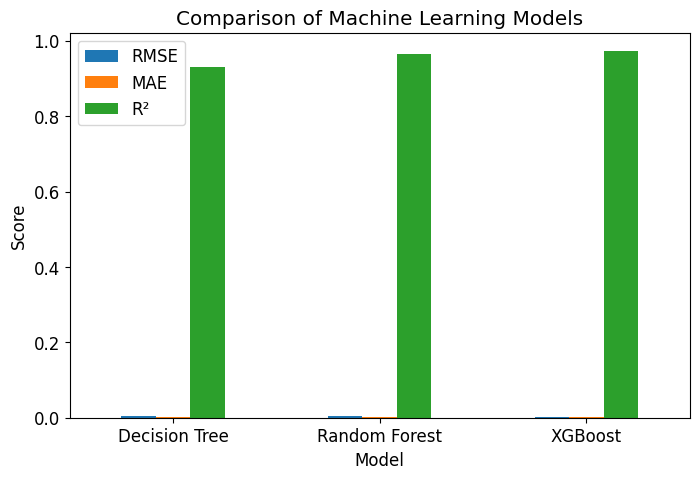

In [65]:
results.set_index("Model")[["RMSE","MAE","R²"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

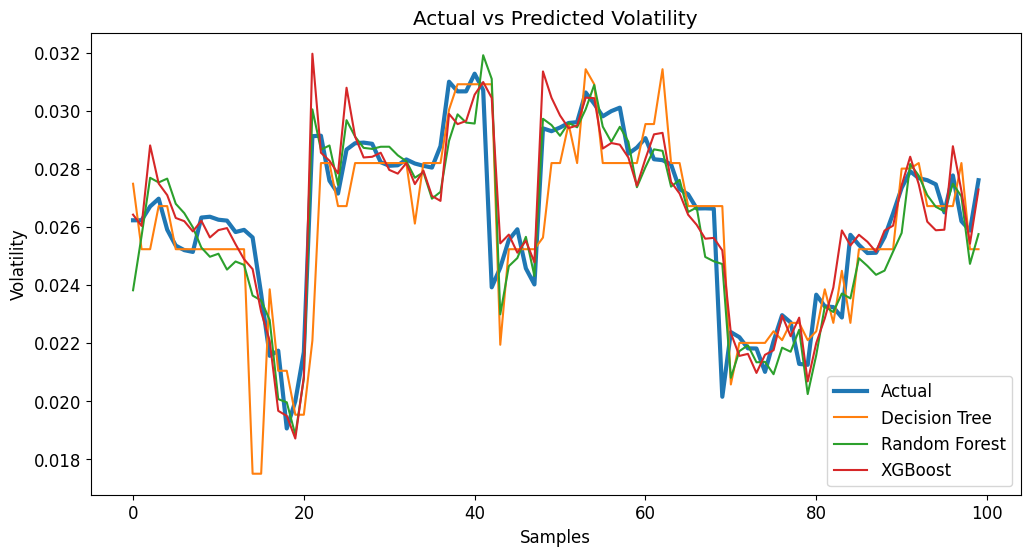

In [66]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual", linewidth=3)

plt.plot(y_pred_dt[:100], label="Decision Tree")

plt.plot(y_pred_rf[:100], label="Random Forest")

plt.plot(y_pred_xgb[:100], label="XGBoost")

plt.title("Actual vs Predicted Volatility")
plt.xlabel("Samples")
plt.ylabel("Volatility")

plt.legend()

plt.show()

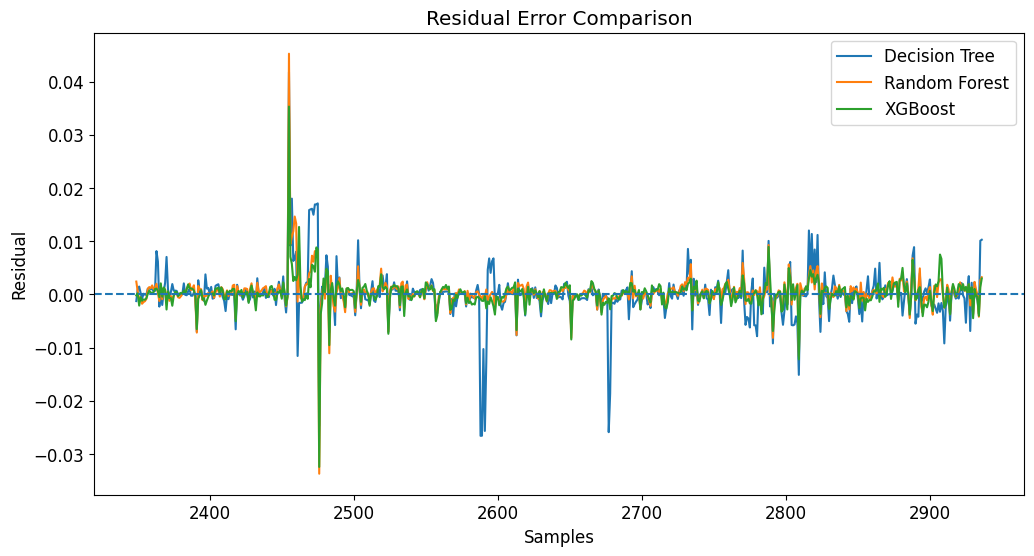

In [67]:
plt.figure(figsize=(12,6))

plt.plot(y_test - y_pred_dt, label="Decision Tree")

plt.plot(y_test - y_pred_rf, label="Random Forest")

plt.plot(y_test - y_pred_xgb, label="XGBoost")

plt.axhline(0, linestyle='--')

plt.title("Residual Error Comparison")
plt.xlabel("Samples")
plt.ylabel("Residual")

plt.legend()

plt.show()

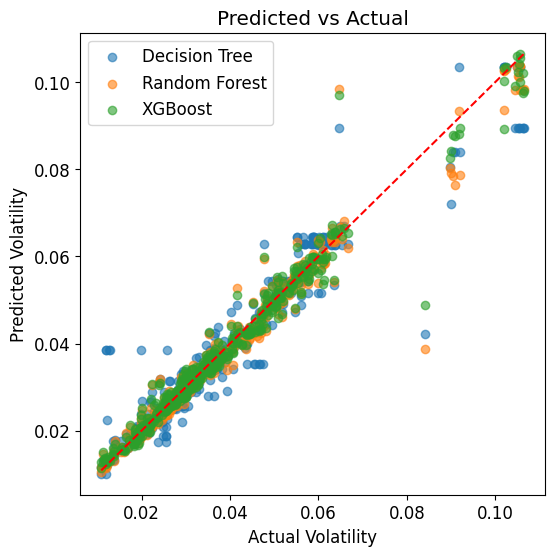

In [68]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_dt, alpha=0.6, label="Decision Tree")

plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest")

plt.scatter(y_test, y_pred_xgb, alpha=0.6, label="XGBoost")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Volatility")
plt.ylabel("Predicted Volatility")
plt.title("Predicted vs Actual")
plt.legend()

plt.show()

In [69]:
!pip install shap

In [70]:
import shap
import matplotlib.pyplot as plt

In [71]:
import pandas as pd

feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf.head(15)

,Feature,Importance
32,Volatility_Lag_1,0.973059
8,Volatility_14,0.010444
33,Volatility_Lag_2,0.003277
7,Volatility_7,0.002109
23,BB_Width,0.001410
6,Returns,0.001069
39,Log_Returns,0.001027
4,Volume,0.000564
18,Stochastic,0.000462
34,Volatility_Lag_3,0.000444


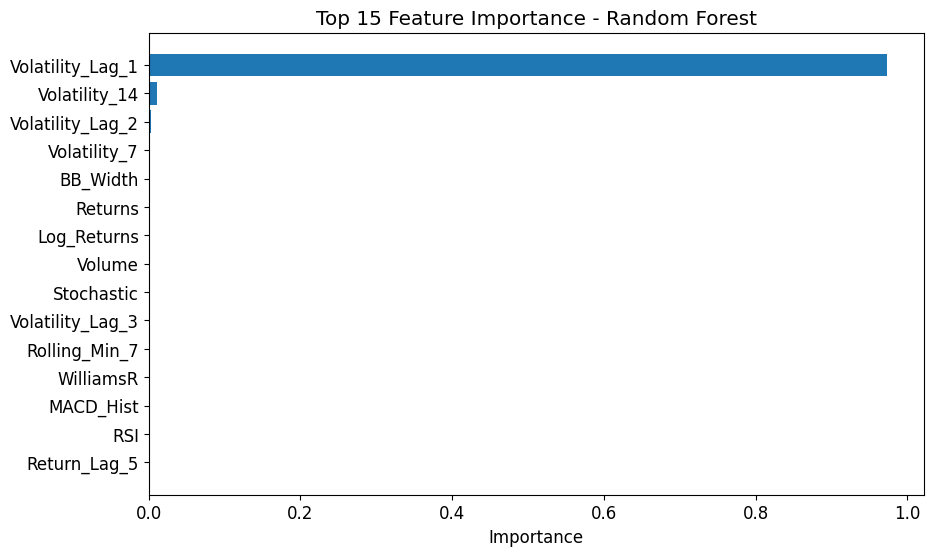

In [72]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_rf["Feature"][:15][::-1],
    feature_importance_rf["Importance"][:15][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importance - Random Forest")

plt.show()

In [73]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(15)

,Feature,Importance
32,Volatility_Lag_1,0.647193
33,Volatility_Lag_2,0.280598
8,Volatility_14,0.018067
22,BB_Middle,0.004503
7,Volatility_7,0.004326
23,BB_Width,0.003526
4,Volume,0.002504
39,Log_Returns,0.002459
12,EMA_20,0.002453
6,Returns,0.002377


In [74]:
feature_importance_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(15)

,Feature,Importance
32,Volatility_Lag_1,0.647193
33,Volatility_Lag_2,0.280598
8,Volatility_14,0.018067
22,BB_Middle,0.004503
7,Volatility_7,0.004326
23,BB_Width,0.003526
4,Volume,0.002504
39,Log_Returns,0.002459
12,EMA_20,0.002453
6,Returns,0.002377


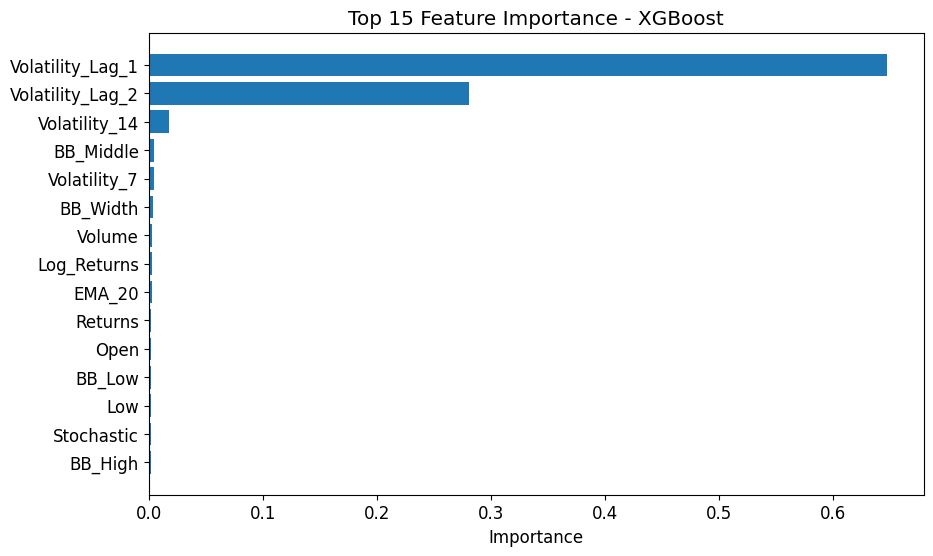

In [75]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb["Feature"][:15][::-1],
    feature_importance_xgb["Importance"][:15][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Feature Importance - XGBoost")

plt.show()

In [76]:
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

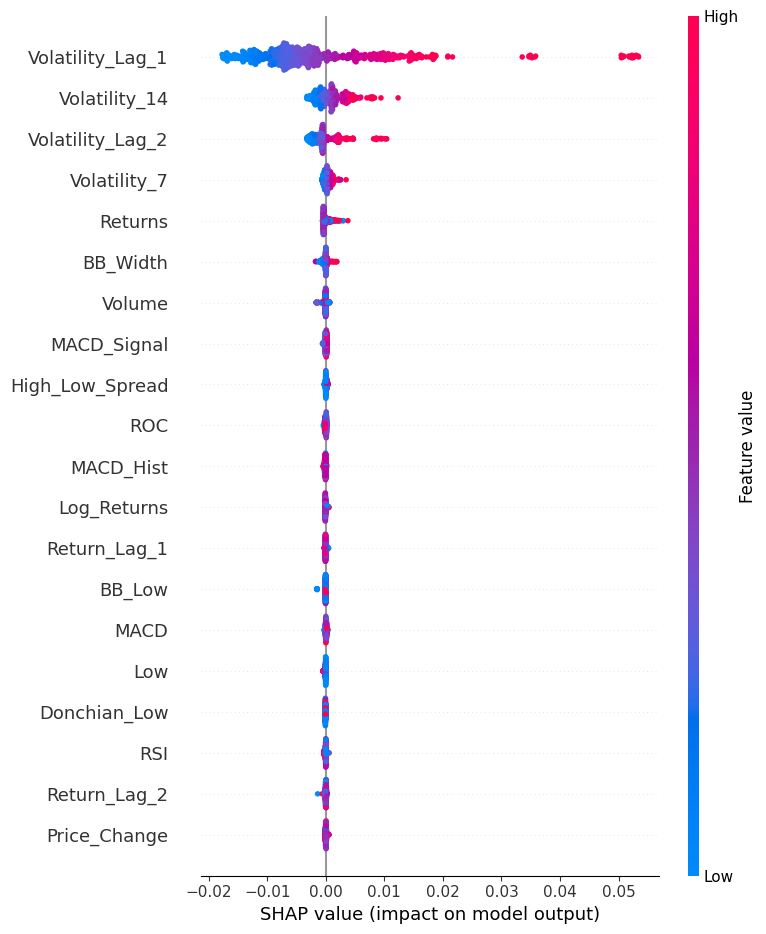

In [77]:
shap.summary_plot(
    shap_values,
    X_test
)

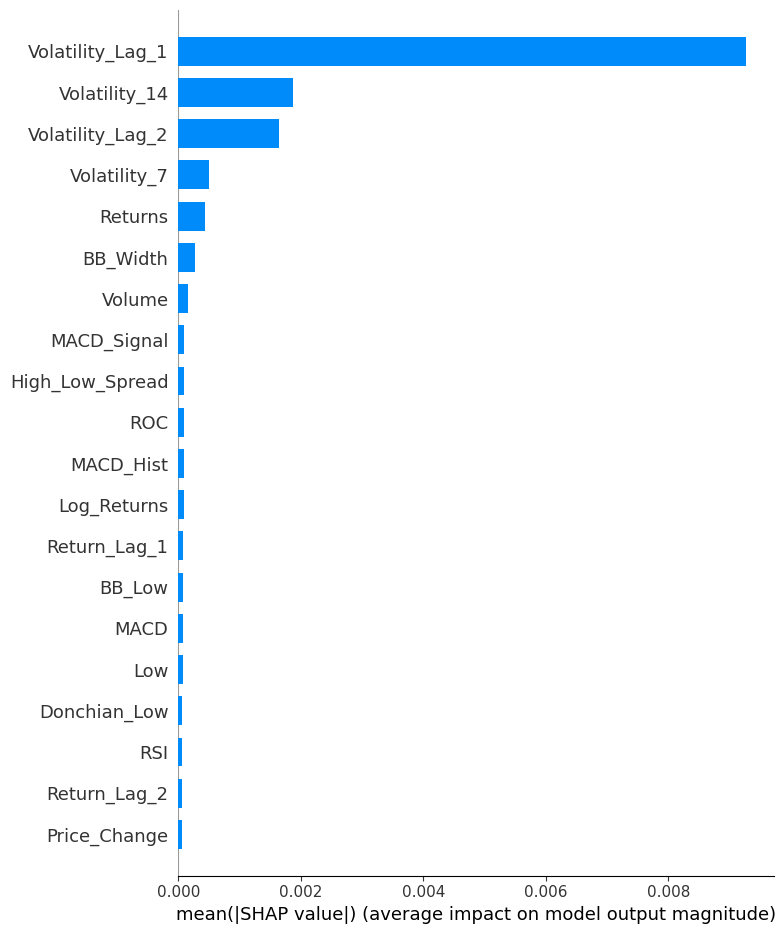

In [78]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

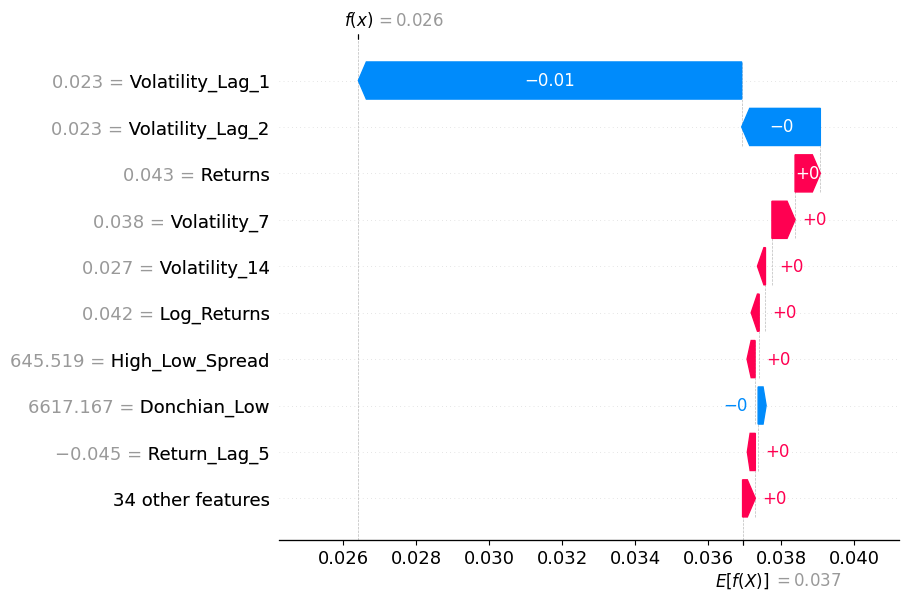

In [79]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [80]:
%who

DecisionTreeRegressor	 RandomForestRegressor	 TimeSeriesSplit	 X	 XGBRegressor	 X_test	 X_train	 comparison_dt	 comparison_xgb	 
corr	 df	 dt	 explainer	 feature_importance	 feature_importance_rf	 feature_importance_xgb	 files	 i	 
importance	 mae_dt	 mae_rf	 mae_xgb	 mean_absolute_error	 mean_squared_error	 np	 numeric_cols	 pd	 
plt	 r2_dt	 r2_rf	 r2_score	 r2_xgb	 results	 rf	 rmse_dt	 rmse_rf	 
rmse_xgb	 shap	 shap_values	 sns	 split	 ta	 uploaded	 v	 warnings	 
xgb	 y	 y_pred_dt	 y_pred_rf	 y_pred_xgb	 y_test	 y_train	 


In [81]:
results_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "RMSE": [rmse_dt, rmse_rf, rmse_xgb],
    "MAE": [mae_dt, mae_rf, mae_xgb],
    "R²": [r2_dt, r2_rf, r2_xgb]
})

results_df

,Model,RMSE,MAE,R²
0,Decision Tree,0.004662,0.002393,0.929451
1,Random Forest,0.003295,0.001578,0.964753
2,XGBoost,0.002884,0.001529,0.973001


In [82]:
results_df.to_csv("model_results.csv", index=False)

In [83]:
import joblib

joblib.dump(xgb, "bitcoin_volatility_xgboost.pkl")

['bitcoin_volatility_xgboost.pkl']

In [84]:
joblib.dump(rf, "bitcoin_volatility_random_forest.pkl")

['bitcoin_volatility_random_forest.pkl']

In [85]:
joblib.dump(dt, "bitcoin_volatility_decision_tree.pkl")

['bitcoin_volatility_decision_tree.pkl']

In [86]:
joblib.dump(list(X_train.columns), "feature_names.pkl")

['feature_names.pkl']

In [87]:
df.to_csv("bitcoin_volatility_final_dataset.csv", index=False)

# CROSS VALIDATION


In [88]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

tscv = TimeSeriesSplit(n_splits=5)

cv_rmse_dt = (-cross_val_score(
    dt,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)).mean()

print("Decision Tree CV RMSE :", cv_rmse_dt)

Decision Tree CV RMSE : 0.00477180828490334


In [89]:
cv_rmse_xgb = (-cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)).mean()

print("XGBoost CV RMSE :", cv_rmse_xgb)

XGBoost CV RMSE : 0.003611717014813106


In [90]:
cv_rmse_rf = (-cross_val_score(
    rf,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)).mean()

print("Random Forest CV RMSE :", cv_rmse_rf)

Random Forest CV RMSE : 0.0030194634531182625


In [91]:
cv_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "CV RMSE": [cv_rmse_dt, cv_rmse_rf, cv_rmse_xgb]
})

cv_results = cv_results.sort_values("CV RMSE")

cv_results

,Model,CV RMSE
1,Random Forest,0.003019
2,XGBoost,0.003612
0,Decision Tree,0.004772


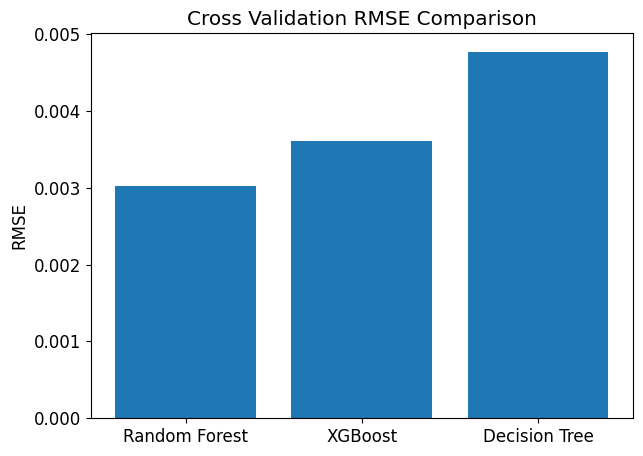

In [92]:
plt.figure(figsize=(7,5))

plt.bar(
    cv_results["Model"],
    cv_results["CV RMSE"]
)

plt.title("Cross Validation RMSE Comparison")
plt.ylabel("RMSE")

plt.show()


#NOW DOING THE VERSION 2 WITHOUT THE VOLATILITY INDICATORS
 -  IN THIS WE ONLY HAVE TECHNICAL INDICATORS NOT THE FULL FEATURE SET

In [93]:
# Create a fresh copy from Version 1 dataset
df_v2 = df.copy()

# Remove only lag volatility features
df_v2 = df_v2.drop(columns=[
    "Volatility_Lag_1",
    "Volatility_Lag_2",
    "Volatility_Lag_3"
])

print("Shape :", df_v2.shape)
df_v2.head()

Shape : (2937, 42)


,Date,High,Low,Open,Close,Volume,Marketcap,Returns,Volatility_7,Volatility_14,...,Return_Lag_5,Return_Lag_7,Rolling_Mean_7,Rolling_STD_7,Rolling_Max_7,Rolling_Min_7,Log_Returns,Price_Change,High_Low_Spread,Open_Close_Spread
0,2013-06-22 23:59:59,109.956001,107.514000,109.500000,108.300003,0.0,1.226110e+09,-0.010959,0.023153,0.036862,...,0.022008,0.000092,106.401429,4.108266,110.150002,99.510002,-0.011019,-1.199997,2.442001,1.199997
1,2013-06-23 23:59:59,108.800003,106.234001,108.199997,107.599998,0.0,1.218626e+09,-0.006464,0.023360,0.029602,...,0.056047,-0.004782,107.557143,2.764724,110.150002,101.699997,-0.006485,-0.599998,2.566002,0.599998
2,2013-06-24 23:59:59,108.334000,100.980003,107.900002,102.737000,0.0,1.163936e+09,-0.045195,0.030895,0.027436,...,0.007914,0.022008,107.705286,2.402644,110.150002,102.737000,-0.046248,-5.163002,7.353996,5.163002
3,2013-06-25 23:59:59,106.470001,101.010002,102.089996,103.949997,0.0,1.178086e+09,0.011807,0.020856,0.026729,...,0.017552,0.056047,107.212429,2.797166,110.150002,102.737000,0.011738,1.860001,5.459999,-1.860001
4,2013-06-26 23:59:59,105.488998,102.792000,103.329002,104.000000,0.0,1.179105e+09,0.000481,0.020303,0.026719,...,-0.005901,0.007914,106.605286,2.989080,110.150002,102.737000,0.000481,0.670998,2.696999,-0.670998


In [94]:
train_v2 = df_v2[df_v2["Date"] < "2019-12-01"]
test_v2 = df_v2[df_v2["Date"] >= "2019-12-01"]

X_train_v2 = train_v2.drop(columns=["Date", "Volatility_21"])
X_test_v2 = test_v2.drop(columns=["Date", "Volatility_21"])

y_train_v2 = train_v2["Volatility_21"]
y_test_v2 = test_v2["Volatility_21"]

print("Training :", X_train_v2.shape)
print("Testing :", X_test_v2.shape)

Training : (2353, 40)
Testing : (584, 40)



 Volatility_21 is our target variable (y).

In [95]:
df_v2.columns

Index(['Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Marketcap',
       'Returns', 'Volatility_7', 'Volatility_14', 'Volatility_21', 'SMA_10',
       'SMA_20', 'EMA_10', 'EMA_20', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI',
       'ROC', 'Stochastic', 'WilliamsR', 'BB_High', 'BB_Low', 'BB_Middle',
       'BB_Width', 'ATR', 'Donchian_High', 'Donchian_Low', 'Return_Lag_1',
       'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_7',
       'Rolling_Mean_7', 'Rolling_STD_7', 'Rolling_Max_7', 'Rolling_Min_7',
       'Log_Returns', 'Price_Change', 'High_Low_Spread', 'Open_Close_Spread'],
      dtype='object')

In [96]:
dt_v2 = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_v2.fit(X_train_v2, y_train_v2)

y_pred_dt_v2 = dt_v2.predict(X_test_v2)

rmse_dt_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_dt_v2))
mae_dt_v2 = mean_absolute_error(y_test_v2, y_pred_dt_v2)
r2_dt_v2 = r2_score(y_test_v2, y_pred_dt_v2)

print("Decision Tree")
print("RMSE :", rmse_dt_v2)
print("MAE :", mae_dt_v2)
print("R² :", r2_dt_v2)

Decision Tree
RMSE : 0.01257199029477432
MAE : 0.008367749023078873
R² : 0.48925126923413154


In [97]:
# Training data
train_v2 = df_v2[df_v2["Date"] < "2019-12-01"]

# Testing data
test_v2 = df_v2[df_v2["Date"] >= "2019-12-01"]

# Features
X_train_v2 = train_v2.drop(columns=["Date", "Volatility_21"])
X_test_v2 = test_v2.drop(columns=["Date", "Volatility_21"])

# Target
y_train_v2 = train_v2["Volatility_21"]
y_test_v2 = test_v2["Volatility_21"]

print("Training Samples :", len(train_v2))
print("Testing Samples  :", len(test_v2))

Training Samples : 2353
Testing Samples  : 584


In [98]:
print("Training Period")
print(train_v2["Date"].min())
print(train_v2["Date"].max())

print()

print("Testing Period")
print(test_v2["Date"].min())
print(test_v2["Date"].max())

Training Period
2013-06-22 23:59:59
2019-11-30 23:59:59

Testing Period
2019-12-01 23:59:59
2021-07-06 23:59:59


In [99]:
dt_v2 = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt_v2.fit(X_train_v2, y_train_v2)

y_pred_dt_v2 = dt_v2.predict(X_test_v2)

rmse_dt_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_dt_v2))
mae_dt_v2 = mean_absolute_error(y_test_v2, y_pred_dt_v2)
r2_dt_v2 = r2_score(y_test_v2, y_pred_dt_v2)

print("Decision Tree")
print("RMSE :", rmse_dt_v2)
print("MAE :", mae_dt_v2)
print("R² :", r2_dt_v2)

Decision Tree
RMSE : 0.01257199029477432
MAE : 0.008367749023078873
R² : 0.48925126923413154


In [100]:
rf_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_v2.fit(X_train_v2, y_train_v2)

y_pred_rf_v2 = rf_v2.predict(X_test_v2)

rmse_rf_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_rf_v2))
mae_rf_v2 = mean_absolute_error(y_test_v2, y_pred_rf_v2)
r2_rf_v2 = r2_score(y_test_v2, y_pred_rf_v2)

print("Random Forest")
print("RMSE :", rmse_rf_v2)
print("MAE :", mae_rf_v2)
print("R² :", r2_rf_v2)

Random Forest
RMSE : 0.012235199717800363
MAE : 0.009238010131307964
R² : 0.516249588391364


In [101]:
xgb_v2 = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_v2.fit(X_train_v2, y_train_v2)

y_pred_xgb_v2 = xgb_v2.predict(X_test_v2)

rmse_xgb_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb_v2))
mae_xgb_v2 = mean_absolute_error(y_test_v2, y_pred_xgb_v2)
r2_xgb_v2 = r2_score(y_test_v2, y_pred_xgb_v2)

print("XGBoost")
print("RMSE :", rmse_xgb_v2)
print("MAE :", mae_xgb_v2)
print("R² :", r2_xgb_v2)

XGBoost
RMSE : 0.00976911237597806
MAE : 0.007206921433404197
R² : 0.691603505594638


In [102]:
results_v2 = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "RMSE": [rmse_dt_v2, rmse_rf_v2, rmse_xgb_v2],
    "MAE": [mae_dt_v2, mae_rf_v2, mae_xgb_v2],
    "R²": [r2_dt_v2, r2_rf_v2, r2_xgb_v2]
})

results_v2 = results_v2.sort_values("RMSE")
results_v2

,Model,RMSE,MAE,R²
2,XGBoost,0.009769,0.007207,0.691604
1,Random Forest,0.012235,0.009238,0.516250
0,Decision Tree,0.012572,0.008368,0.489251


In [103]:
print(rmse_dt_v2, mae_dt_v2, r2_dt_v2)

0.01257199029477432 0.008367749023078873 0.48925126923413154


In [104]:
print(rmse_rf_v2, mae_rf_v2, r2_rf_v2)

0.012235199717800363 0.009238010131307964 0.516249588391364


In [105]:
print(rmse_xgb_v2, mae_xgb_v2, r2_xgb_v2)

0.00976911237597806 0.007206921433404197 0.691603505594638


In [106]:
comparison_versions = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],

    "RMSE_V1": [rmse_dt, rmse_rf, rmse_xgb],
    "RMSE_V2": [rmse_dt_v2, rmse_rf_v2, rmse_xgb_v2],

    "MAE_V1": [mae_dt, mae_rf, mae_xgb],
    "MAE_V2": [mae_dt_v2, mae_rf_v2, mae_xgb_v2],

    "R2_V1": [r2_dt, r2_rf, r2_xgb],
    "R2_V2": [r2_dt_v2, r2_rf_v2, r2_xgb_v2]
})

comparison_versions

,Model,RMSE_V1,RMSE_V2,MAE_V1,MAE_V2,R2_V1,R2_V2
0,Decision Tree,0.004662,0.012572,0.002393,0.008368,0.929451,0.489251
1,Random Forest,0.003295,0.012235,0.001578,0.009238,0.964753,0.516250
2,XGBoost,0.002884,0.009769,0.001529,0.007207,0.973001,0.691604


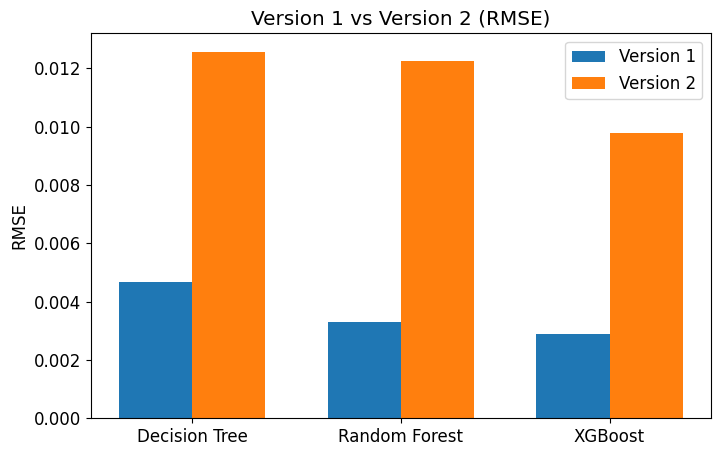

In [107]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(comparison_versions))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x-width/2, comparison_versions["RMSE_V1"], width, label="Version 1")
plt.bar(x+width/2, comparison_versions["RMSE_V2"], width, label="Version 2")

plt.xticks(x, comparison_versions["Model"])
plt.ylabel("RMSE")
plt.title("Version 1 vs Version 2 (RMSE)")
plt.legend()

plt.show()

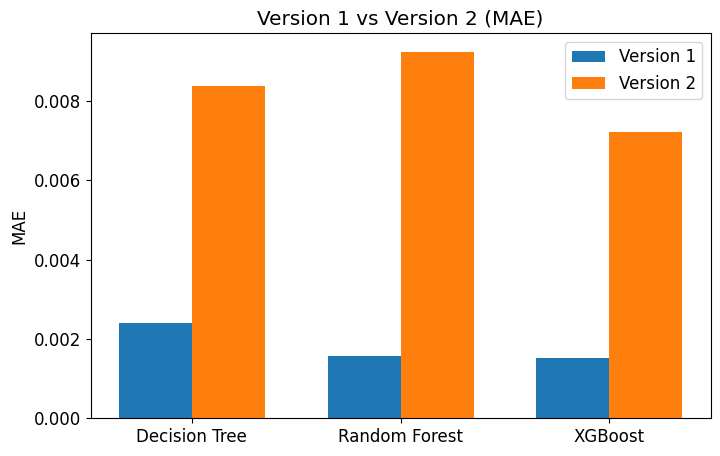

In [108]:
plt.figure(figsize=(8,5))

plt.bar(x-width/2, comparison_versions["MAE_V1"], width, label="Version 1")
plt.bar(x+width/2, comparison_versions["MAE_V2"], width, label="Version 2")

plt.xticks(x, comparison_versions["Model"])
plt.ylabel("MAE")
plt.title("Version 1 vs Version 2 (MAE)")
plt.legend()

plt.show()

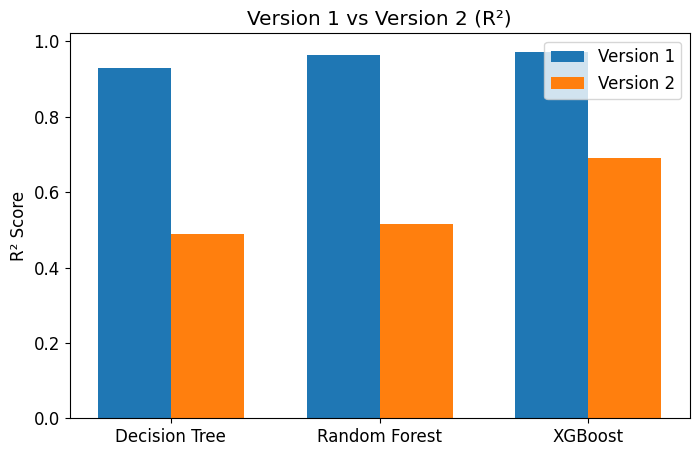

In [109]:
plt.figure(figsize=(8,5))

plt.bar(x-width/2, comparison_versions["R2_V1"], width, label="Version 1")
plt.bar(x+width/2, comparison_versions["R2_V2"], width, label="Version 2")

plt.xticks(x, comparison_versions["Model"])
plt.ylabel("R² Score")
plt.title("Version 1 vs Version 2 (R²)")
plt.legend()

plt.show()

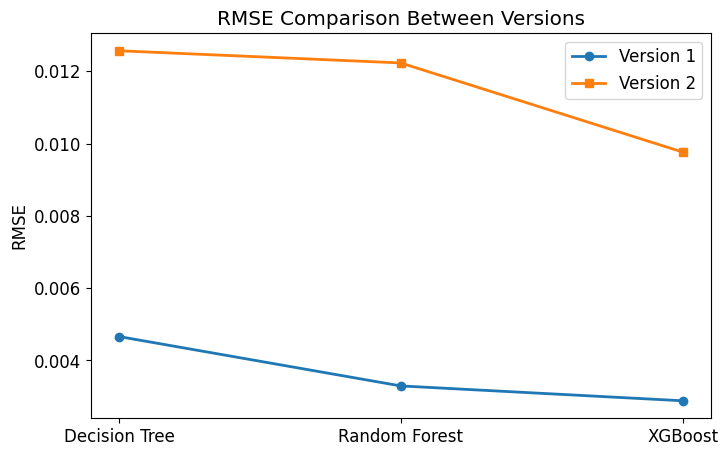

In [110]:
plt.figure(figsize=(8,5))

plt.plot(comparison_versions["Model"],
         comparison_versions["RMSE_V1"],
         marker='o',
         linewidth=2,
         label="Version 1")

plt.plot(comparison_versions["Model"],
         comparison_versions["RMSE_V2"],
         marker='s',
         linewidth=2,
         label="Version 2")

plt.title("RMSE Comparison Between Versions")
plt.ylabel("RMSE")
plt.legend()

plt.show()

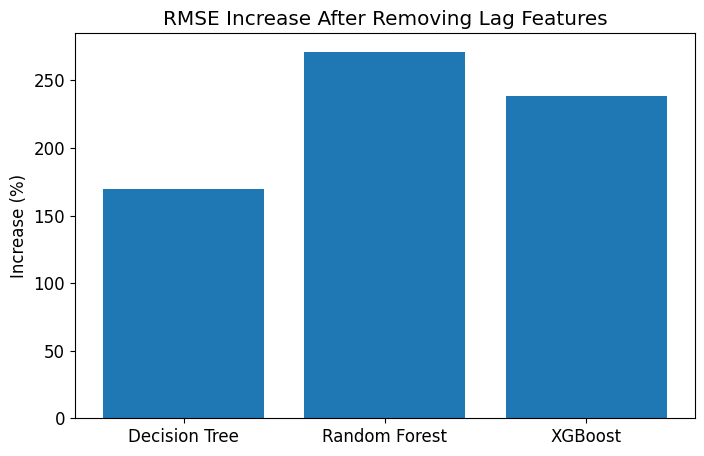

In [111]:
comparison_versions["RMSE Increase (%)"] = (
    (comparison_versions["RMSE_V2"] - comparison_versions["RMSE_V1"])
    / comparison_versions["RMSE_V1"] * 100
)

plt.figure(figsize=(8,5))

plt.bar(comparison_versions["Model"],
        comparison_versions["RMSE Increase (%)"])

plt.ylabel("Increase (%)")
plt.title("RMSE Increase After Removing Lag Features")

plt.show()

In [112]:
import shap

explainer_v2 = shap.TreeExplainer(xgb_v2)

shap_values_v2 = explainer_v2.shap_values(X_test_v2)

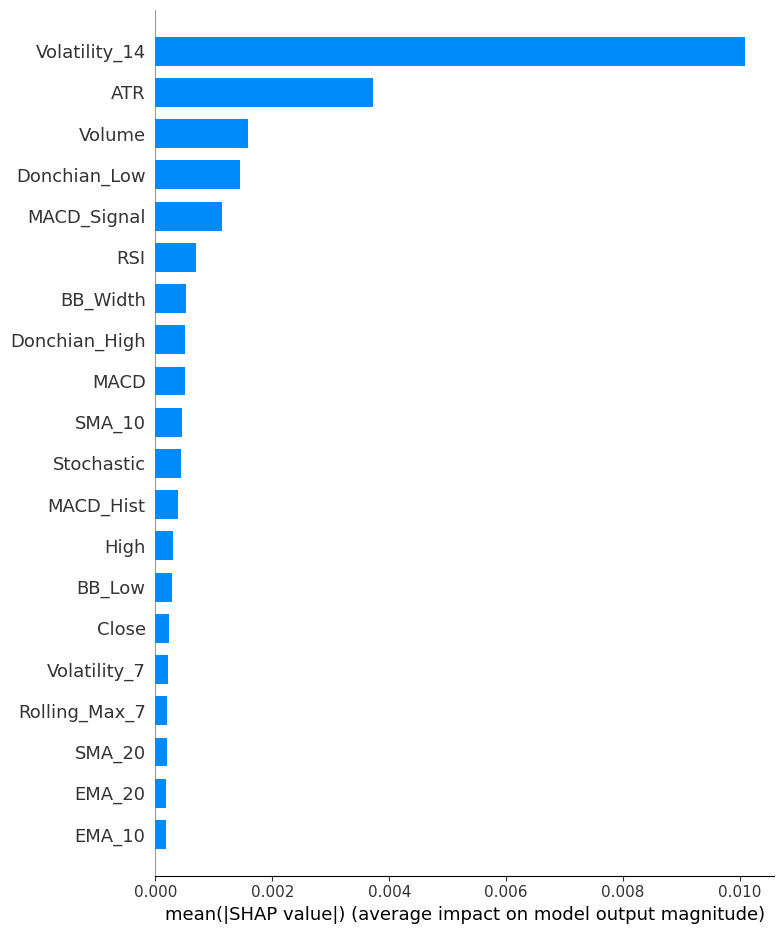

In [113]:
shap.summary_plot(
    shap_values_v2,
    X_test_v2,
    plot_type="bar"
)

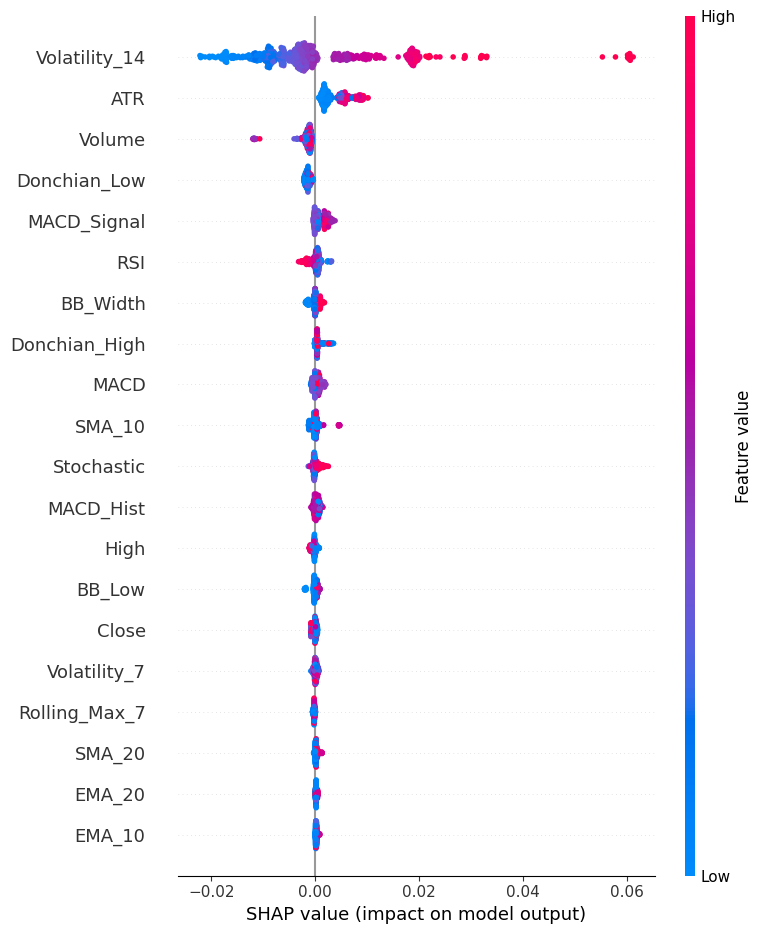

In [114]:
shap.summary_plot(
    shap_values_v2,
    X_test_v2
)

In [115]:
import pandas as pd
import numpy as np

shap_importance_v2 = pd.DataFrame({
    "Feature": X_test_v2.columns,
    "Mean_SHAP": np.abs(shap_values_v2).mean(axis=0)
})

shap_importance_v2 = shap_importance_v2.sort_values(
    "Mean_SHAP",
    ascending=False
)

shap_importance_v2.head(15)

,Feature,Mean_SHAP
8,Volatility_14,0.010077
24,ATR,0.003724
4,Volume,0.001580
26,Donchian_Low,0.001455
14,MACD_Signal,0.001140
16,RSI,0.000701
23,BB_Width,0.000531
25,Donchian_High,0.000515
13,MACD,0.000504
9,SMA_10,0.000449


#HYPERPARAMETRER TUNING FOR BOTH VERSIONS


In [116]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

In [117]:
tscv = TimeSeriesSplit(n_splits=5)

In [118]:
from sklearn.tree import DecisionTreeRegressor

dt_params = {
    "max_depth": [3,5,7,10,15,20,None],
    "min_samples_split": [2,5,10,20],
    "min_samples_leaf": [1,2,4,8],
    "max_features": [None, "sqrt", "log2"]
}

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_distributions=dt_params,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

print("Best Parameters:")
print(dt_search.best_params_)

Best Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 7}


In [119]:
best_dt = dt_search.best_estimator_

y_pred_dt_best = best_dt.predict(X_test)

In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_dt_best = np.sqrt(mean_squared_error(y_test, y_pred_dt_best))
mae_dt_best = mean_absolute_error(y_test, y_pred_dt_best)
r2_dt_best = r2_score(y_test, y_pred_dt_best)

print("Decision Tree (Tuned)")
print("----------------------")
print("RMSE :", rmse_dt_best)
print("MAE  :", mae_dt_best)
print("R²   :", r2_dt_best)

Decision Tree (Tuned)
----------------------
RMSE : 0.0037798893099037336
MAE  : 0.0019154982207720338
R²   : 0.9536209823427656


In [121]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}


In [124]:
best_rf = rf_search.best_estimator_

y_pred_rf_best = best_rf.predict(X_test)

rmse_rf_best = np.sqrt(mean_squared_error(y_test, y_pred_rf_best))
mae_rf_best = mean_absolute_error(y_test, y_pred_rf_best)
r2_rf_best = r2_score(y_test, y_pred_rf_best)

print("Random Forest (Tuned)")
print("----------------------")
print("RMSE :", rmse_rf_best)
print("MAE  :", mae_rf_best)
print("R²   :", r2_rf_best)

Random Forest (Tuned)
----------------------
RMSE : 0.009146906907124223
MAE  : 0.007033720496776581
R²   : 0.728411172907091


In [125]:
from xgboost import XGBRegressor

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_distributions=xgb_params,
    n_iter=20,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [126]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_best = best_xgb.predict(X_test)

rmse_xgb_best = np.sqrt(mean_squared_error(y_test, y_pred_xgb_best))
mae_xgb_best = mean_absolute_error(y_test, y_pred_xgb_best)
r2_xgb_best = r2_score(y_test, y_pred_xgb_best)

print("XGBoost (Tuned)")
print("----------------")
print("RMSE :", rmse_xgb_best)
print("MAE  :", mae_xgb_best)
print("R²   :", r2_xgb_best)

XGBoost (Tuned)
----------------
RMSE : 0.0029668885468110266
MAE  : 0.0015570985702052342
R²   : 0.971426341791579


In [127]:
import joblib

joblib.dump(best_dt, "decision_tree_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")
joblib.dump(xgb, "xgboost_model.pkl")
joblib.dump(list(X_train.columns), "feature_names.pkl")

['feature_names.pkl']

In [128]:
import os

os.makedirs("models", exist_ok=True)

In [130]:
import joblib

# Save Decision Tree (Tuned)
joblib.dump(best_dt, "models/decision_tree_model.pkl")

# Save Random Forest (Original)
joblib.dump(rf, "models/random_forest_model.pkl")

# Save XGBoost (Original)
joblib.dump(xgb, "models/xgboost_model.pkl")

print(" Models saved successfully!")

 Models saved successfully!


In [132]:
joblib.dump(list(X_train.columns), "models/feature_names.pkl")

print(" Feature names saved!")

 Feature names saved!


In [133]:
df.to_csv("models/final_bitcoin_dataset.csv", index=False)

print(" Final dataset saved!")

 Final dataset saved!


In [134]:
import os

os.makedirs("images", exist_ok=True)

In [135]:
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [136]:
plt.savefig("images/closing_price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [137]:
plt.savefig("images/bitcoin_price_trend.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [138]:
plt.savefig("images/actual_vs_predicted_rf.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [139]:
plt.savefig("images/actual_vs_predicted_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [140]:
plt.savefig("images/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [142]:
plt.savefig("images/feature_importance_xgb.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

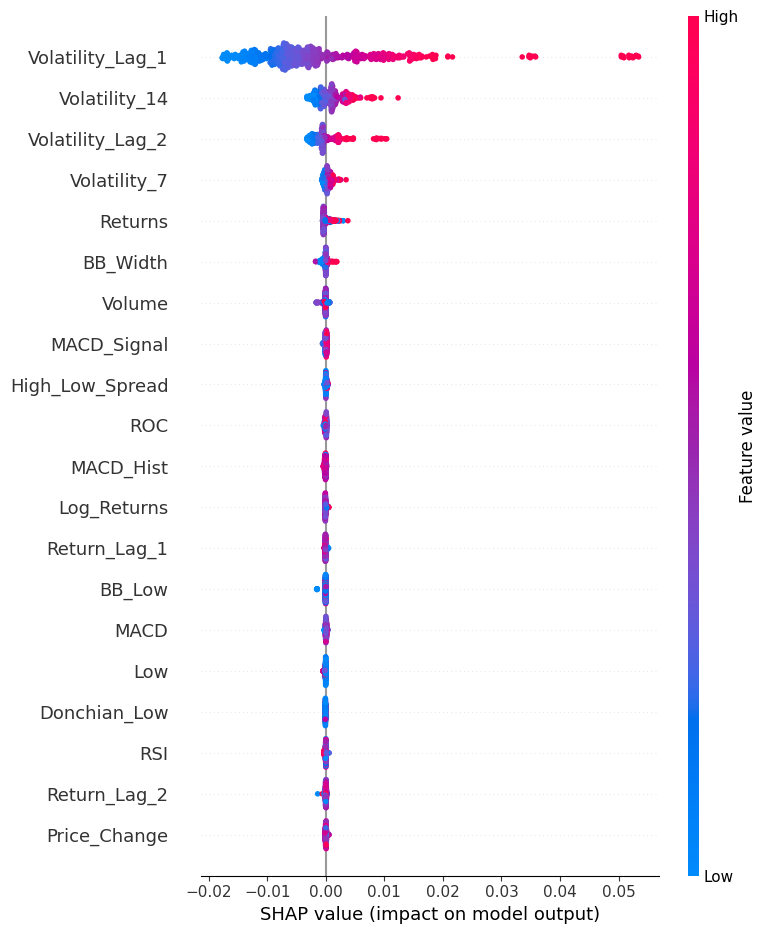

In [143]:
shap.summary_plot(shap_values, X_test, show=False)

plt.savefig(
    "images/shap_summary_v1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

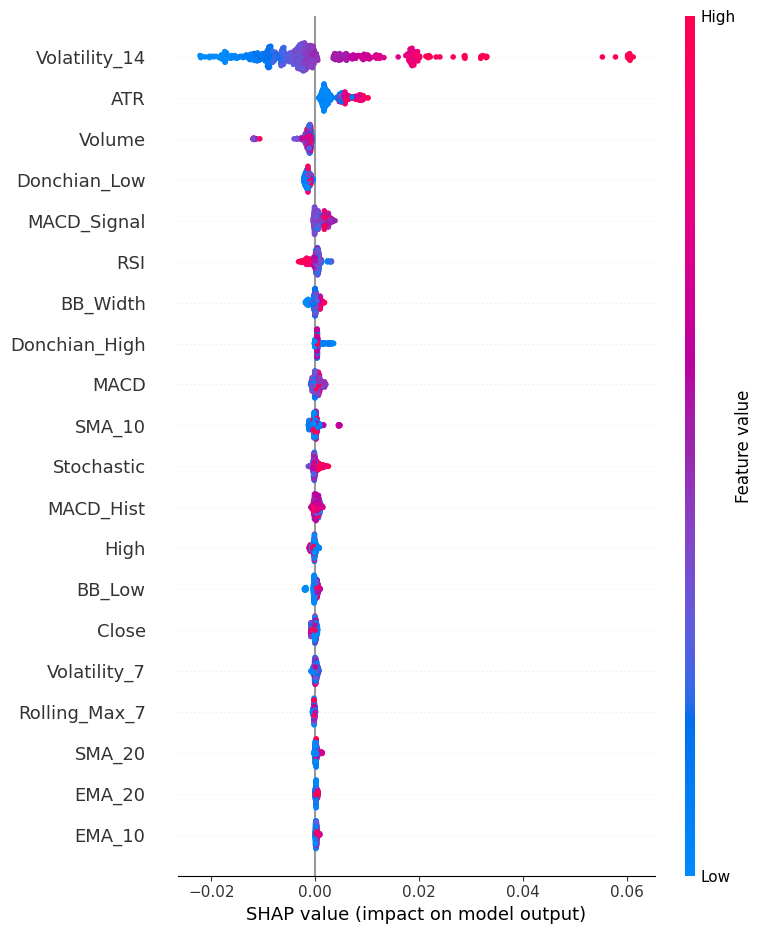

In [144]:
shap.summary_plot(shap_values_v2, X_test_v2, show=False)

plt.savefig(
    "images/shap_summary_v2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [145]:
plt.savefig("images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [146]:
plt.savefig("images/version_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1400x600 with 0 Axes>

In [147]:
import shutil

shutil.make_archive("bitcoin_images", "zip", "images")

'/content/bitcoin_images.zip'

In [148]:
from google.colab import files

files.download("bitcoin_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Hyperparameter tuning improved the Decision Tree model by reducing RMSE from 0.004598 to 0.003780 and increasing R² from 0.9317 to 0.9536. However, the original Random Forest and XGBoost models outperformed their tuned counterparts on the hold-out test set. Therefore, the best-performing version of each model was selected for the final comparison.

# Conclusion

This study developed a machine learning framework for Bitcoin volatility prediction using historical market data and technical indicators. Decision Tree, Random Forest, and XGBoost models were evaluated using a time-series train-test split and TimeSeriesSplit cross-validation. Among all models, XGBoost achieved the best predictive performance, demonstrating the effectiveness of ensemble learning for volatility forecasting.

Feature importance analysis and SHAP explainability revealed that historical volatility and technical indicators were the most influential predictors. An additional feature ablation study (Version 2) further confirmed the significance of lagged volatility features, as removing them resulted in a noticeable decline in model performance.

Overall, the proposed framework provides an accurate and interpretable approach for Bitcoin volatility prediction and can serve as a foundation for future research involving real-time forecasting, alternative data sources, and advanced deep learning models.


# Limitations

1. This project uses only historical Bitcoin price data and technical indicators. It does not consider news, social media sentiment, or economic events that can affect Bitcoin prices.

2. The model is trained only on Bitcoin data, so its performance on other cryptocurrencies has not been tested.

3. The model predicts volatility based on past market behavior. It may not accurately predict sudden market crashes or unexpected events.

4. The dataset used is from 2013 to 2021. The model has not been tested on newer market data.

5. Although hyperparameter tuning was performed, trying more parameter combinations could further improve the model.

# Future Work

1. Add news sentiment and social media data to improve prediction accuracy.

2. Test advanced deep learning models such as LSTM, GRU, or Transformer.

3. Train and evaluate the model on other cryptocurrencies like Ethereum and Solana.

4. Build a real-time prediction system using live Bitcoin market data.

5. Improve the Streamlit application by adding charts, prediction history, and a better user interface.

6. Try more advanced hyperparameter tuning methods to further improve model performance.